In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os 

In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/skin lesion/0_data/HAM10000_metadata.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [6]:
for i in df.columns:
    print(i,"-->" ,df[i].nunique())
    print()

lesion_id --> 7470

image_id --> 10015

dx --> 7

dx_type --> 4

age --> 18

sex --> 3

localization --> 15



In [ ]:
print(df['dx'].unique())
print(df['dx_type'].unique())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
['histo' 'consensus' 'confocal' 'follow_up']


In [8]:
df['localization'].unique()

array(['scalp', 'ear', 'face', 'back', 'trunk', 'chest',
       'upper extremity', 'abdomen', 'unknown', 'lower extremity',
       'genital', 'neck', 'hand', 'foot', 'acral'], dtype=object)

In [10]:
df['sex'].value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

In [11]:
df['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [16]:
df['localization'].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

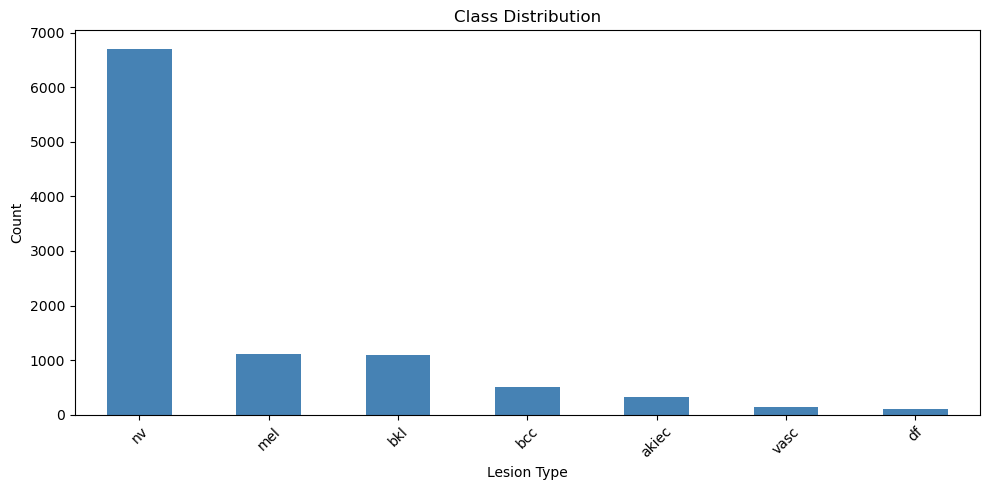

In [18]:
plt.figure(figsize=(10, 5))
df['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution')
plt.xlabel('Lesion Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
img_dir_1 = '/media/prince/5A4E832F4E83034D/skin lesion/0_data/ham10000_images_part_1'
img_dir_2 = '/media/prince/5A4E832F4E83034D/skin lesion/0_data/ham10000_images_part_2'

In [22]:
def get_image_path(image_id):
    for folder in [img_dir_1, img_dir_2]:
        path = os.path.join(folder, image_id + '.jpg')
        if os.path.exists(path):
            return path
    return None

df['path'] = df['image_id'].apply(get_image_path)
print("Missing images:", df['path'].isnull().sum())

Missing images: 0


In [27]:
sample = df.sample(5)
for _, row in sample.iterrows():
    img = Image.open(row['path'])
    print(row['image_id'], img.size)

ISIC_0029765 (600, 450)
ISIC_0026329 (600, 450)
ISIC_0032656 (600, 450)
ISIC_0026748 (600, 450)
ISIC_0029893 (600, 450)


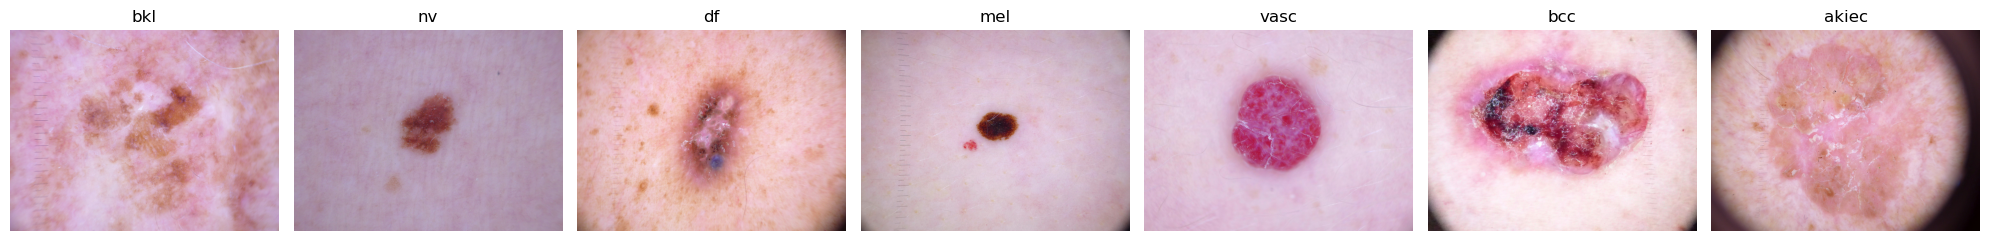

In [28]:
classes = df['dx'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(20, 4))
for ax, cls in zip(axes, classes):
    sample_row = df[df['dx'] == cls].iloc[0]
    img = Image.open(sample_row['path'])
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.tight_layout()
plt.show()